In [33]:
import pandas as pd
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn .feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score


In [34]:
# DATA LOADING
df= pd.read_csv('/content/youtube.csv')
df.head()

,link,title,description,category
0,JLZlCZ0,Ep 1| Travelling through North East India | Of...,Tanya Khanijow\n671K subscribers\nSUBSCRIBE\nT...,travel
1,i9E_Blai8vk,Welcome to Bali | Travel Vlog | Priscilla Lee,Priscilla Lee\n45.6K subscribers\nSUBSCRIBE\n*...,travel
2,r284c-q8oY,My Solo Trip to ALASKA | Cruising From Vancouv...,Allison Anderson\n588K subscribers\nSUBSCRIBE\...,travel
3,Qmi-Xwq-ME,Traveling to the Happiest Country in the World!!,Yes Theory\n6.65M subscribers\nSUBSCRIBE\n*BLA...,travel
4,_lcOX55Ef70,Solo in Paro Bhutan | Tiger's Nest visit | Bhu...,Tanya Khanijow\n671K subscribers\nSUBSCRIBE\nH...,travel


In [35]:
# DATA PRE-PROCESSING & CLEANING
def clean_text(text):
    # Convert to lowercase
    text = str(text).lower()
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Remove punctuation using a translation table
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [36]:
# Feature Engineering: Combine Title and Description for better context
df['combined_text'] = df['title'].fillna(' ') + df['description'].fillna('')
df['clean_text']=df['combined_text'].apply(clean_text)

In [37]:
#  DATA SPLITTING

X = df['clean_text']
y = df['category']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

In [38]:
#  VECTORIZATION (TF-IDF)

tfidf=TfidfVectorizer(max_features=5000 ,stop_words='english',ngram_range=(1,2))
X_train_tfidf=tfidf.fit_transform(X_train)
x_test_tfidf=tfidf.transform(X_test)

In [39]:
#  MODEL BUILDING (Machine Learning)
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [42]:
# Model Evaluation
y_pred = model.predict(x_test_tfidf)

In [43]:
# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy:.2%}\n")

Overall Accuracy: 95.42%



In [44]:
# Detailed Classification Report (Precision, Recall, F1-Score)
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

   art_music       1.00      0.95      0.97       189
        food       0.95      0.95      0.95       181
     history       0.97      0.93      0.95       119
      travel       0.92      0.97      0.95       231

    accuracy                           0.95       720
   macro avg       0.96      0.95      0.95       720
weighted avg       0.96      0.95      0.95       720



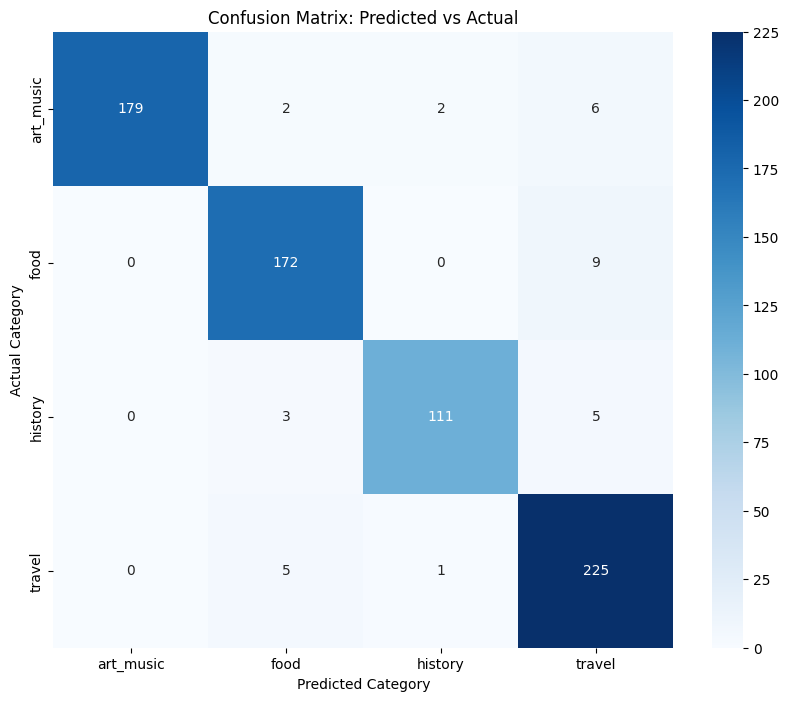

In [45]:
#  VISUALIZATION (Confusion Matrix)
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.title('Confusion Matrix: Predicted vs Actual')
plt.xlabel('Predicted Category')
plt.ylabel('Actual Category')
plt.show()